In [1]:
import scanpy as sc
import numpy as np
import pandas as pd

from plotnine import *
from scipy.stats import pearsonr, spearmanr

sc.set_figure_params(figsize = (5, 5))


/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/setuptools_scm/_integration/setuptools.py:31: RuntimeWarning: 
ERROR: setuptools==58.1.0 is used in combination with setuptools_scm>=8.x

Your build configuration is incomplete and previously worked by accident!
setuptools_scm requires setuptools>=61

Suggested workaround if applicable:
 - migrating from the deprecated setup_requires mechanism to pep517/518
   and using a pyproject.toml to declare build dependencies
   which are reliably pre-installed before running the build tools

  warnings.warn(


In [2]:
sc.settings.figdir = "fig6_plots/"


In [3]:
peak_ad = sc.read_h5ad("../current_merged_sc_peaks.h5ad")

In [4]:
archetype_naming = {
    "k8_aa_0": "Cd8 naive arch",
    "k8_aa_1": "Cd8 mem arch",
    "k8_aa_2": "Cd4 Tfh arch",
    "k8_aa_3": "Cd8 dys arch",
    "k8_aa_4": "T cell activation arch",
    "k8_aa_5": "Cd8 eff arch",
    "k8_aa_6": "Cd4 Treg arch",
    "k8_aa_7": "Cd4 naive-mem arch"
}

In [5]:
for k in archetype_naming.keys(): 
    peak_ad.obs[archetype_naming[k]] = list(peak_ad.obs[k])

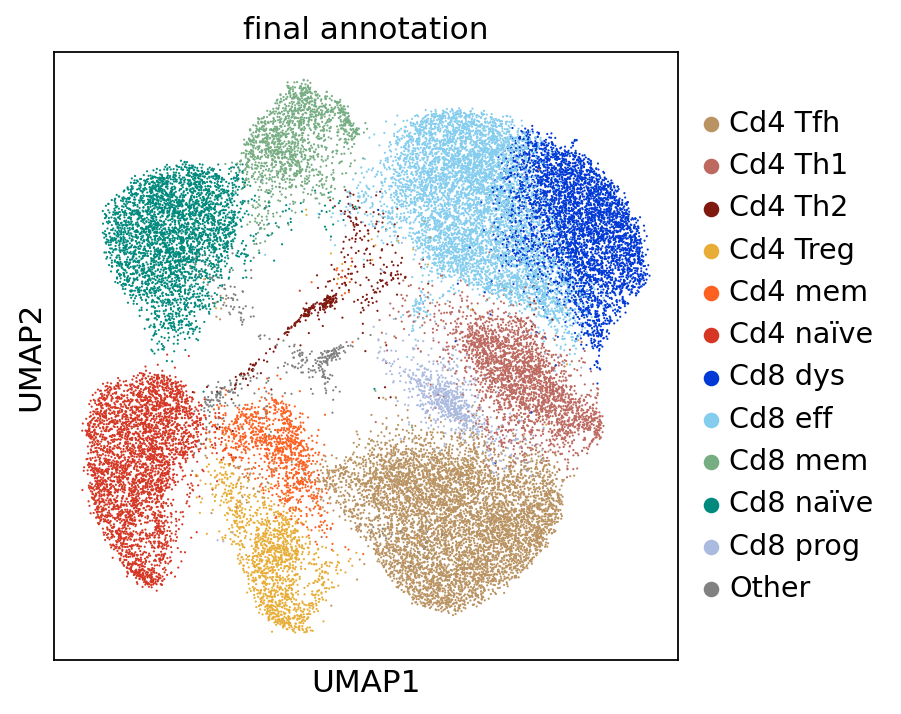

In [6]:
sc.pl.umap(peak_ad, color = "final annotation")

In [7]:
from scipy.stats import kstest

test_arch_res = pd.DataFrame()
for cl in ["Cd4 Tfh", "Cd8 prog", "Cd8 dys", "Cd4 Th1"]:
    for a in archetype_naming.values():
        arm_vals = peak_ad[(peak_ad.obs["final annotation"] == cl) & (peak_ad.obs["sample"] == "arm")].obs[a]
        cl13_vals = peak_ad[(peak_ad.obs["final annotation"] == cl) & (peak_ad.obs["sample"] == "cl13")].obs[a]
        pval = kstest(arm_vals, cl13_vals)[1]
        diff_med = np.median(arm_vals) - np.median(cl13_vals)
        test_arch_res = pd.concat([test_arch_res, pd.DataFrame({"annot": [cl], "pval": [pval], "diff medians":
                                                                [diff_med], "arch": [a]})])

In [8]:
test_arch_res[(test_arch_res["pval"] <= 0.05/test_arch_res.shape[0]) & (np.abs(test_arch_res[
    "diff medians"]) > 0.05)]

,annot,pval,diff medians,arch
0,Cd4 Tfh,9.728738e-13,-0.062562,Cd4 Tfh arch
0,Cd4 Tfh,3.706466e-124,0.164566,Cd4 naive-mem arch
0,Cd8 prog,2.142589e-71,0.185106,Cd8 naive arch
0,Cd8 prog,3.542744e-12,-0.062161,Cd4 Tfh arch
0,Cd8 prog,6.086733e-06,-0.063221,Cd8 dys arch
0,Cd8 dys,1.363621e-321,0.070715,Cd8 naive arch
0,Cd8 dys,6.018954e-20,-0.087045,T cell activation arch
0,Cd4 Th1,3.102759e-14,-0.102701,T cell activation arch
0,Cd4 Th1,3.737601e-16,0.084553,Cd8 eff arch
0,Cd4 Th1,2.636475e-185,0.182056,Cd4 naive-mem arch


## Panel A

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/anndata/_core/anndata.py:1235: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.


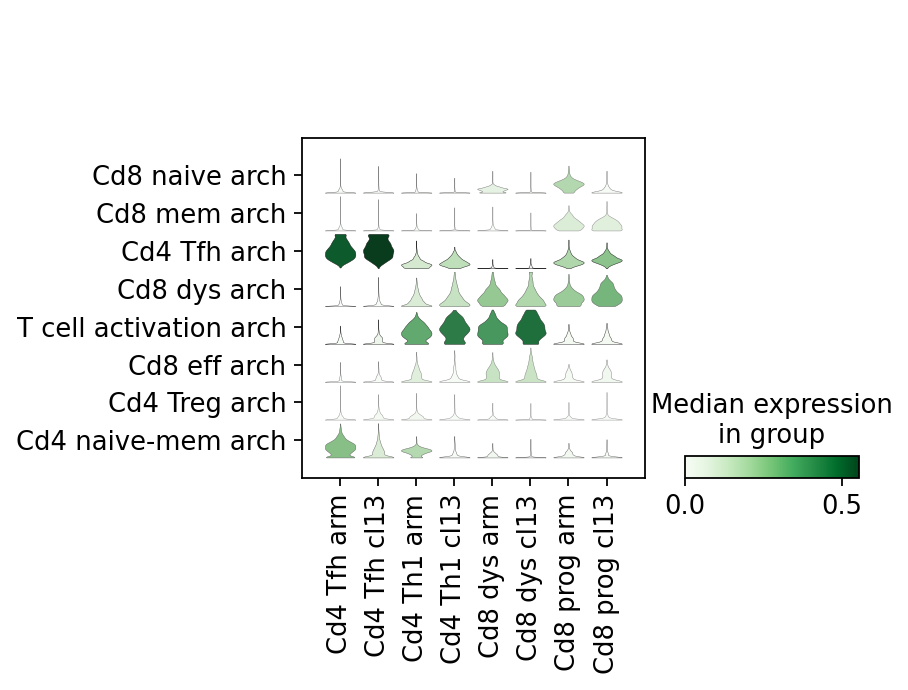

In [9]:
peak_ad.obs["samp_annot"] =  peak_ad.obs["final annotation"].astype(str) + " " + peak_ad.obs[
    "sample"].astype(str)

sc.pl.stacked_violin(peak_ad[peak_ad.obs["final annotation"].isin(["Cd4 Tfh", "Cd8 prog", "Cd8 dys", "Cd4 Th1"])],
             var_names = list(archetype_naming.values()), groupby = "samp_annot", cmap = "Greens", save = 
                    "panel_a.pdf", swap_axes = True)

In [10]:
samp_colors = {"arm": "#69659a", "cl13": "#709585"}
from scipy.stats import kstest

def make_plot(ct, arch = "Cd4 Tfh arch"):
    pvalue_comp = pd.DataFrame({"samp 1": s1, "samp2": s2, "pval": kstest(peak_ad.obs[(peak_ad.obs[
        "final annotation"] == ct) & (peak_ad.obs["sample"] == "arm") & (peak_ad.obs["batch"] == s1)][
        arch], peak_ad.obs[(peak_ad.obs["final annotation"] == ct) & (peak_ad.obs["sample"] == "cl13") & (
        peak_ad.obs["batch"] == s2)][arch])[1]} for s1 in ["mult", "scatac"] for s2 in ["mult", "scatac"])
    print(pvalue_comp)
    return ggplot(peak_ad[peak_ad.obs["final annotation"] == ct].obs, aes(
        x = arch, color = "sample", linetype = "batch")) + theme_tufte() + theme(dpi = 200, figure_size = (
        3, 3)) + scale_color_manual(samp_colors) + stat_ecdf() + labs(title = "max KS test pval in %s: %.2E"%(
        ct, pvalue_comp["pval"].max()))

## PANEL B

   samp 1   samp2          pval
0    mult    mult  1.039419e-08
1    mult  scatac  1.019244e-05
2  scatac    mult  1.777353e-07
3  scatac  scatac  8.053985e-06


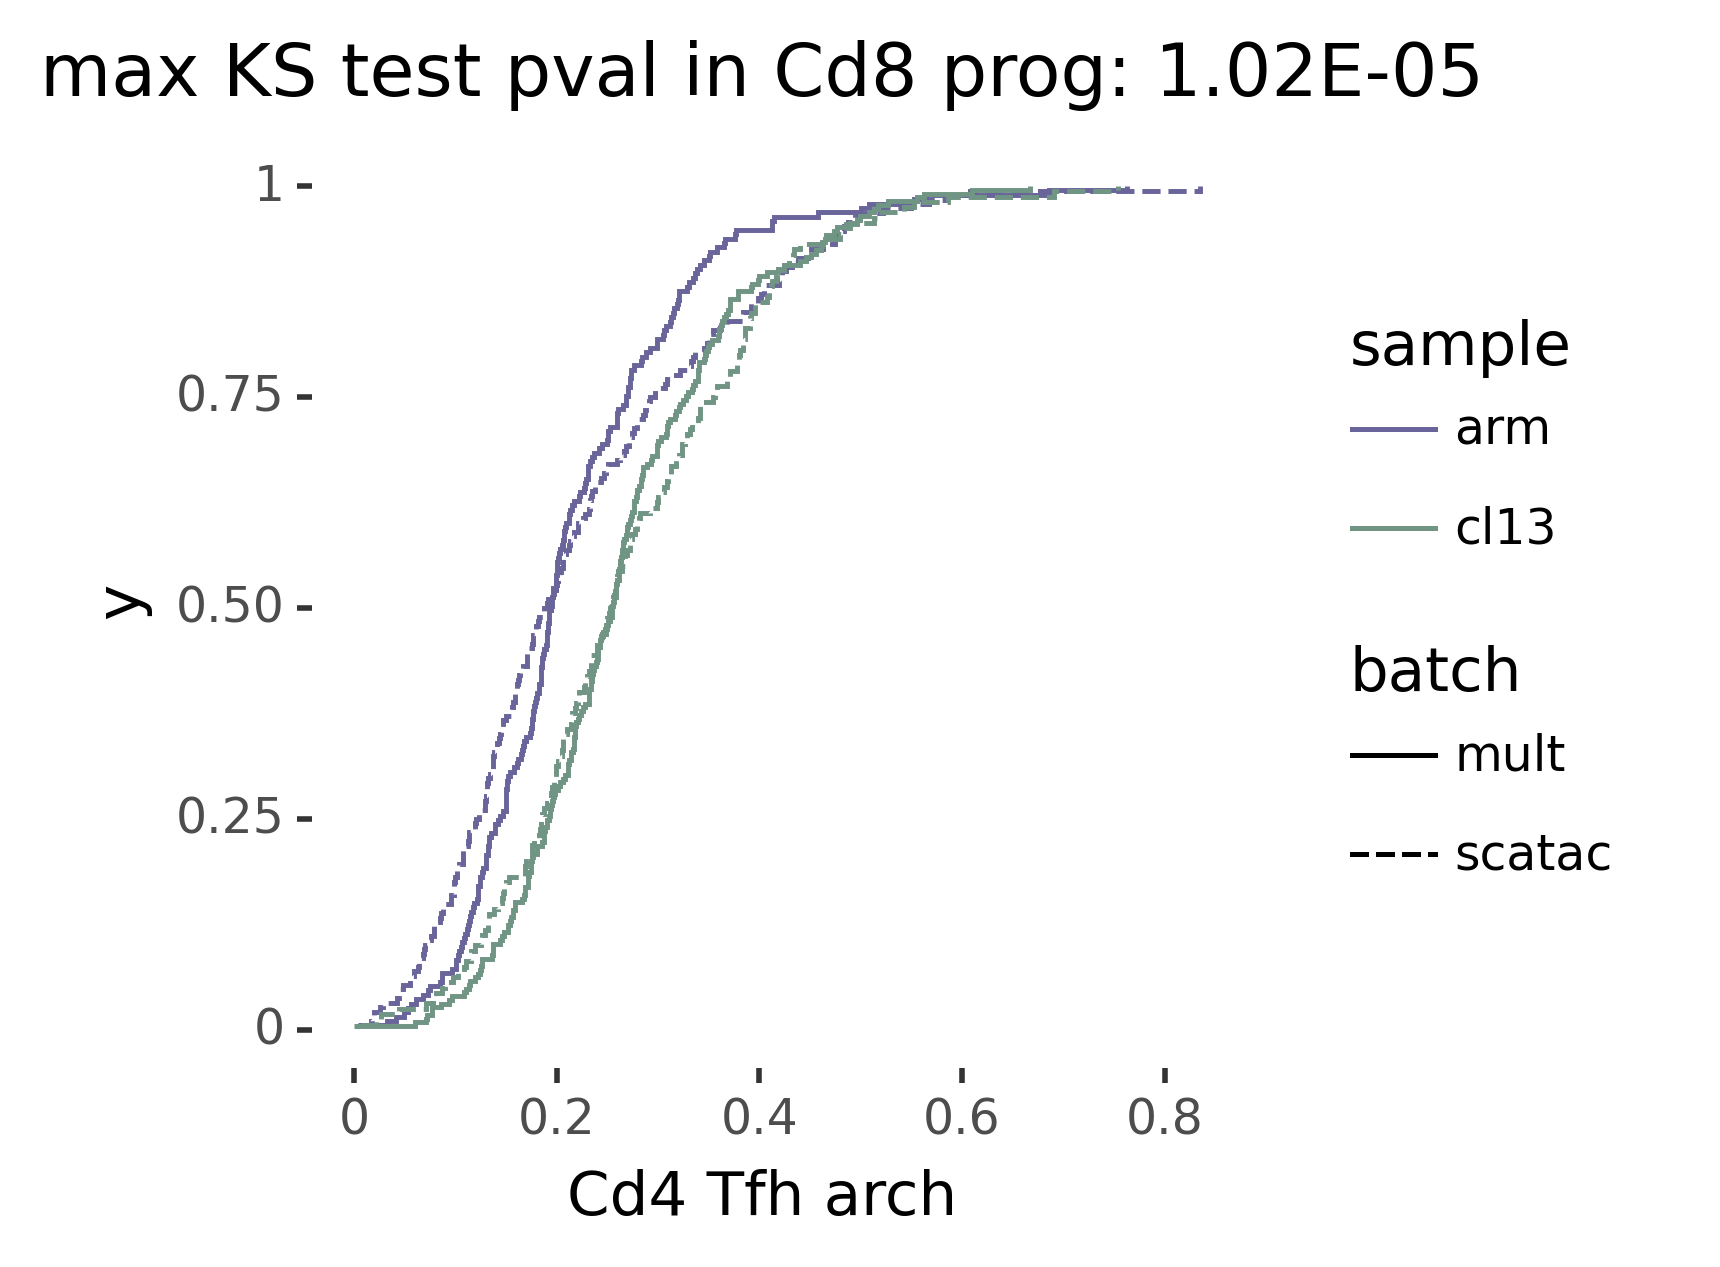

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 3 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig6_plots/prog_cdf_tfh_arch.pdf


In [11]:
prog =  make_plot("Cd8 prog")
print(prog)
ggsave(prog, "fig6_plots/prog_cdf_tfh_arch.pdf", dpi = 300)

   samp 1   samp2          pval
0    mult    mult  3.232209e-14
1    mult  scatac  1.358709e-06
2  scatac    mult  4.093682e-07
3  scatac  scatac  3.290060e-03


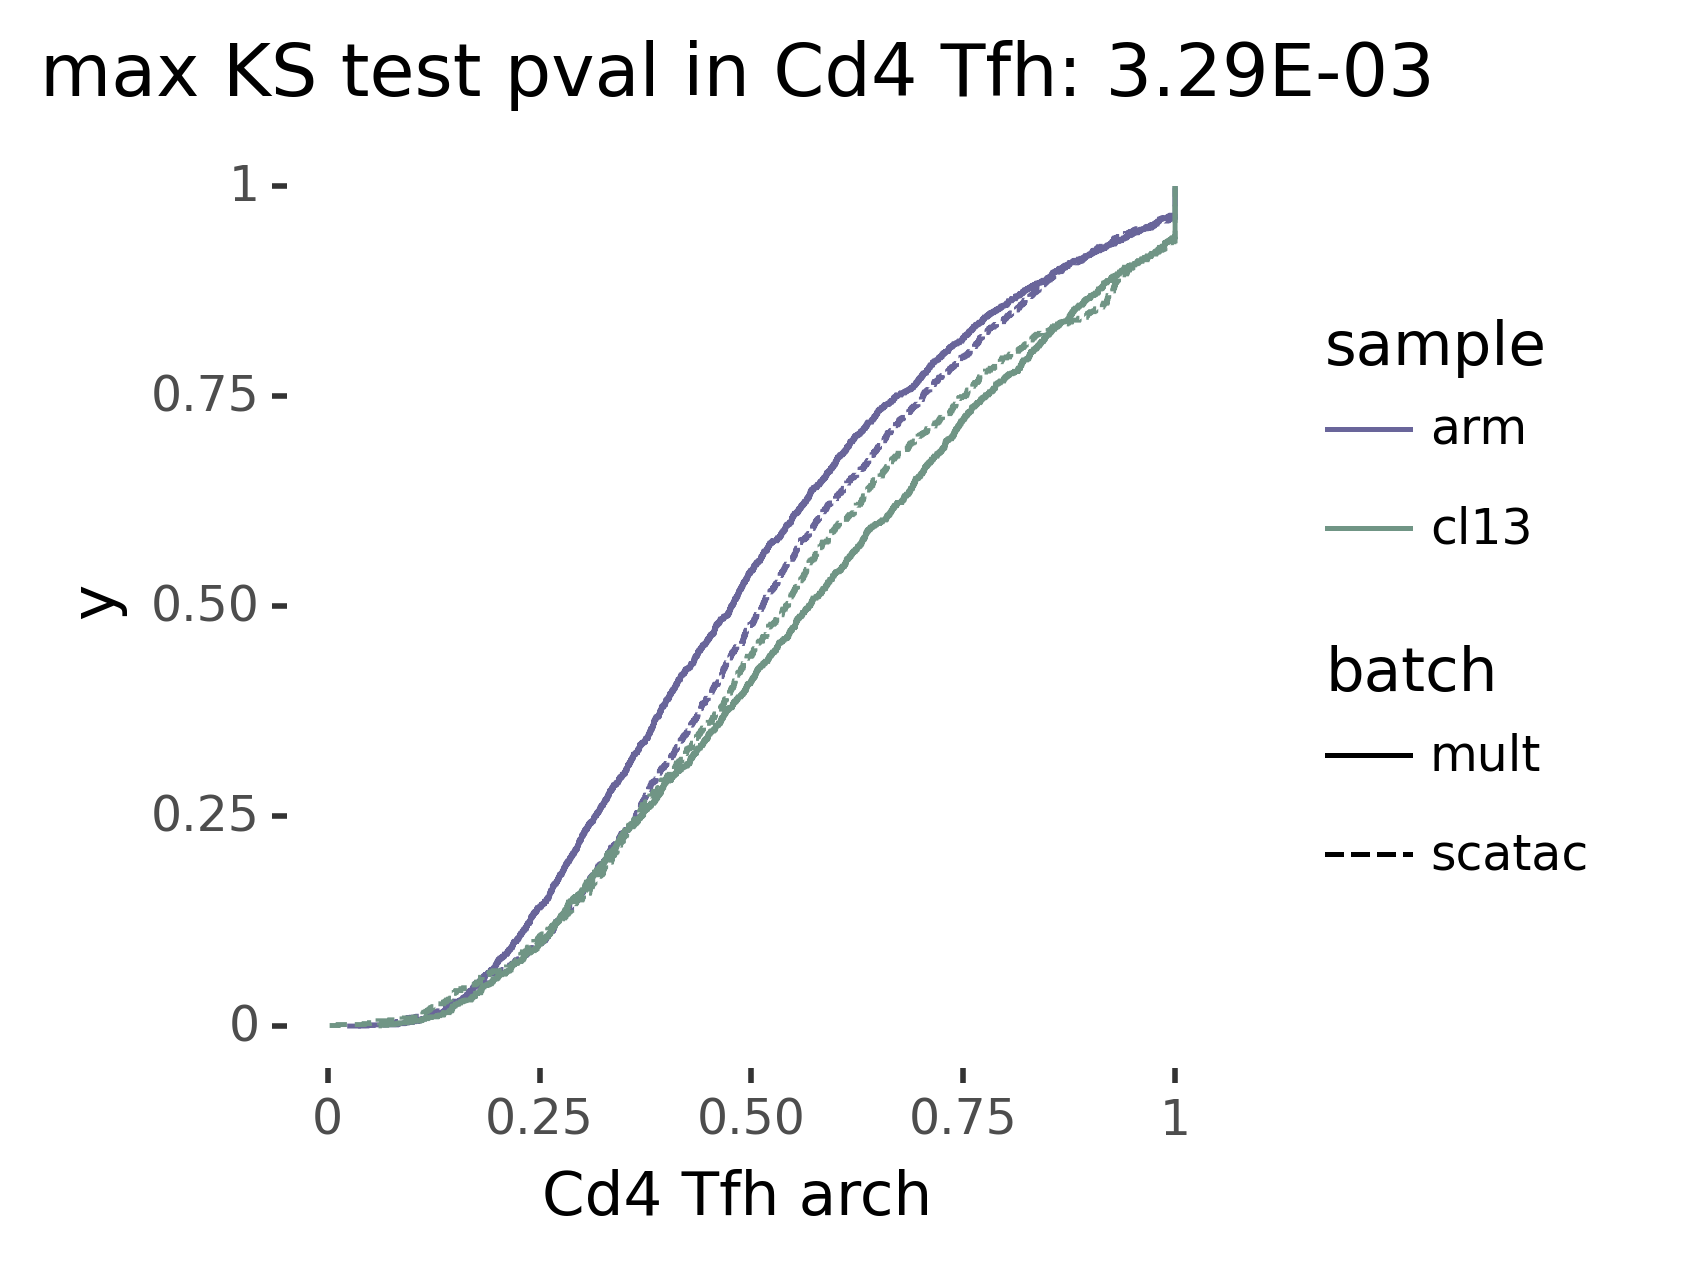

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 3 x 3 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig6_plots/tfh_cdf_tfh_arch.pdf


In [12]:
tfh =  make_plot("Cd4 Tfh")
print(tfh)
ggsave(tfh, "fig6_plots/tfh_cdf_tfh_arch.pdf", dpi = 300)

## PANEL C: in code for figure 5

## PANEL D: in illustrator

In [13]:
rna = sc.read_h5ad("anndatas/my_rna_modality.h5ad")

In [14]:
def get_neighbor_fraction(i, ad, col = "sample"):
    neighbors = ad.obs_names[ad.obsp["connectivities"][i, :].nonzero()[1]]
    #     return np.sum(ad.obs.loc[neighbors, "final annotation"].isin([ "Cd4 Tfh"]))/len(neighbors)
    return np.sum(ad.obs.loc[neighbors, col] == "arm")/len(neighbors)

rna.obs["fr_neighbors_armstrong"] = [ get_neighbor_fraction(i, rna, "type") for i in range(
    rna.shape[0])]

In [15]:
rna.obs["Cd4 Tfh arch"] = list(peak_ad.obs.loc[rna.obs_names]["Cd4 Tfh arch"])

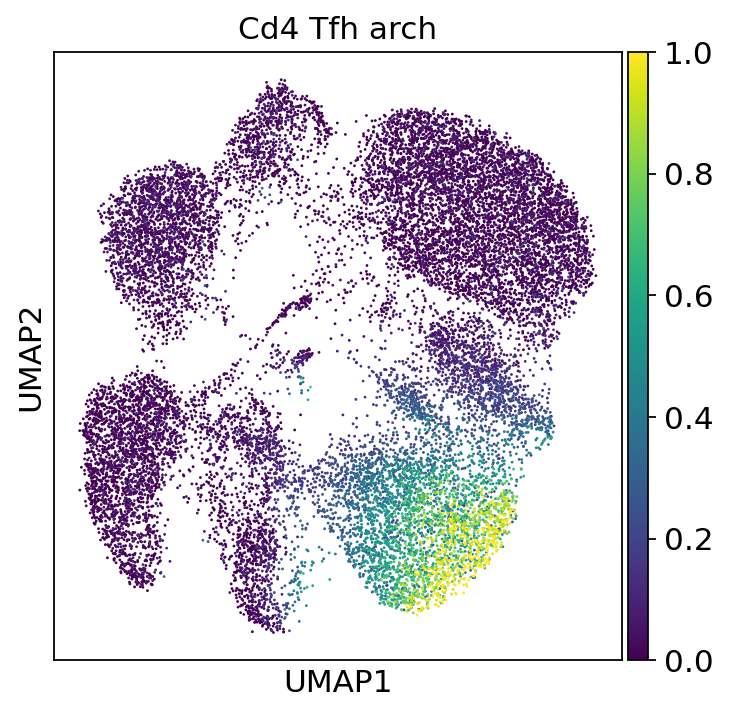

In [16]:
sc.pl.umap(rna, color = "Cd4 Tfh arch")

## PANEL E:

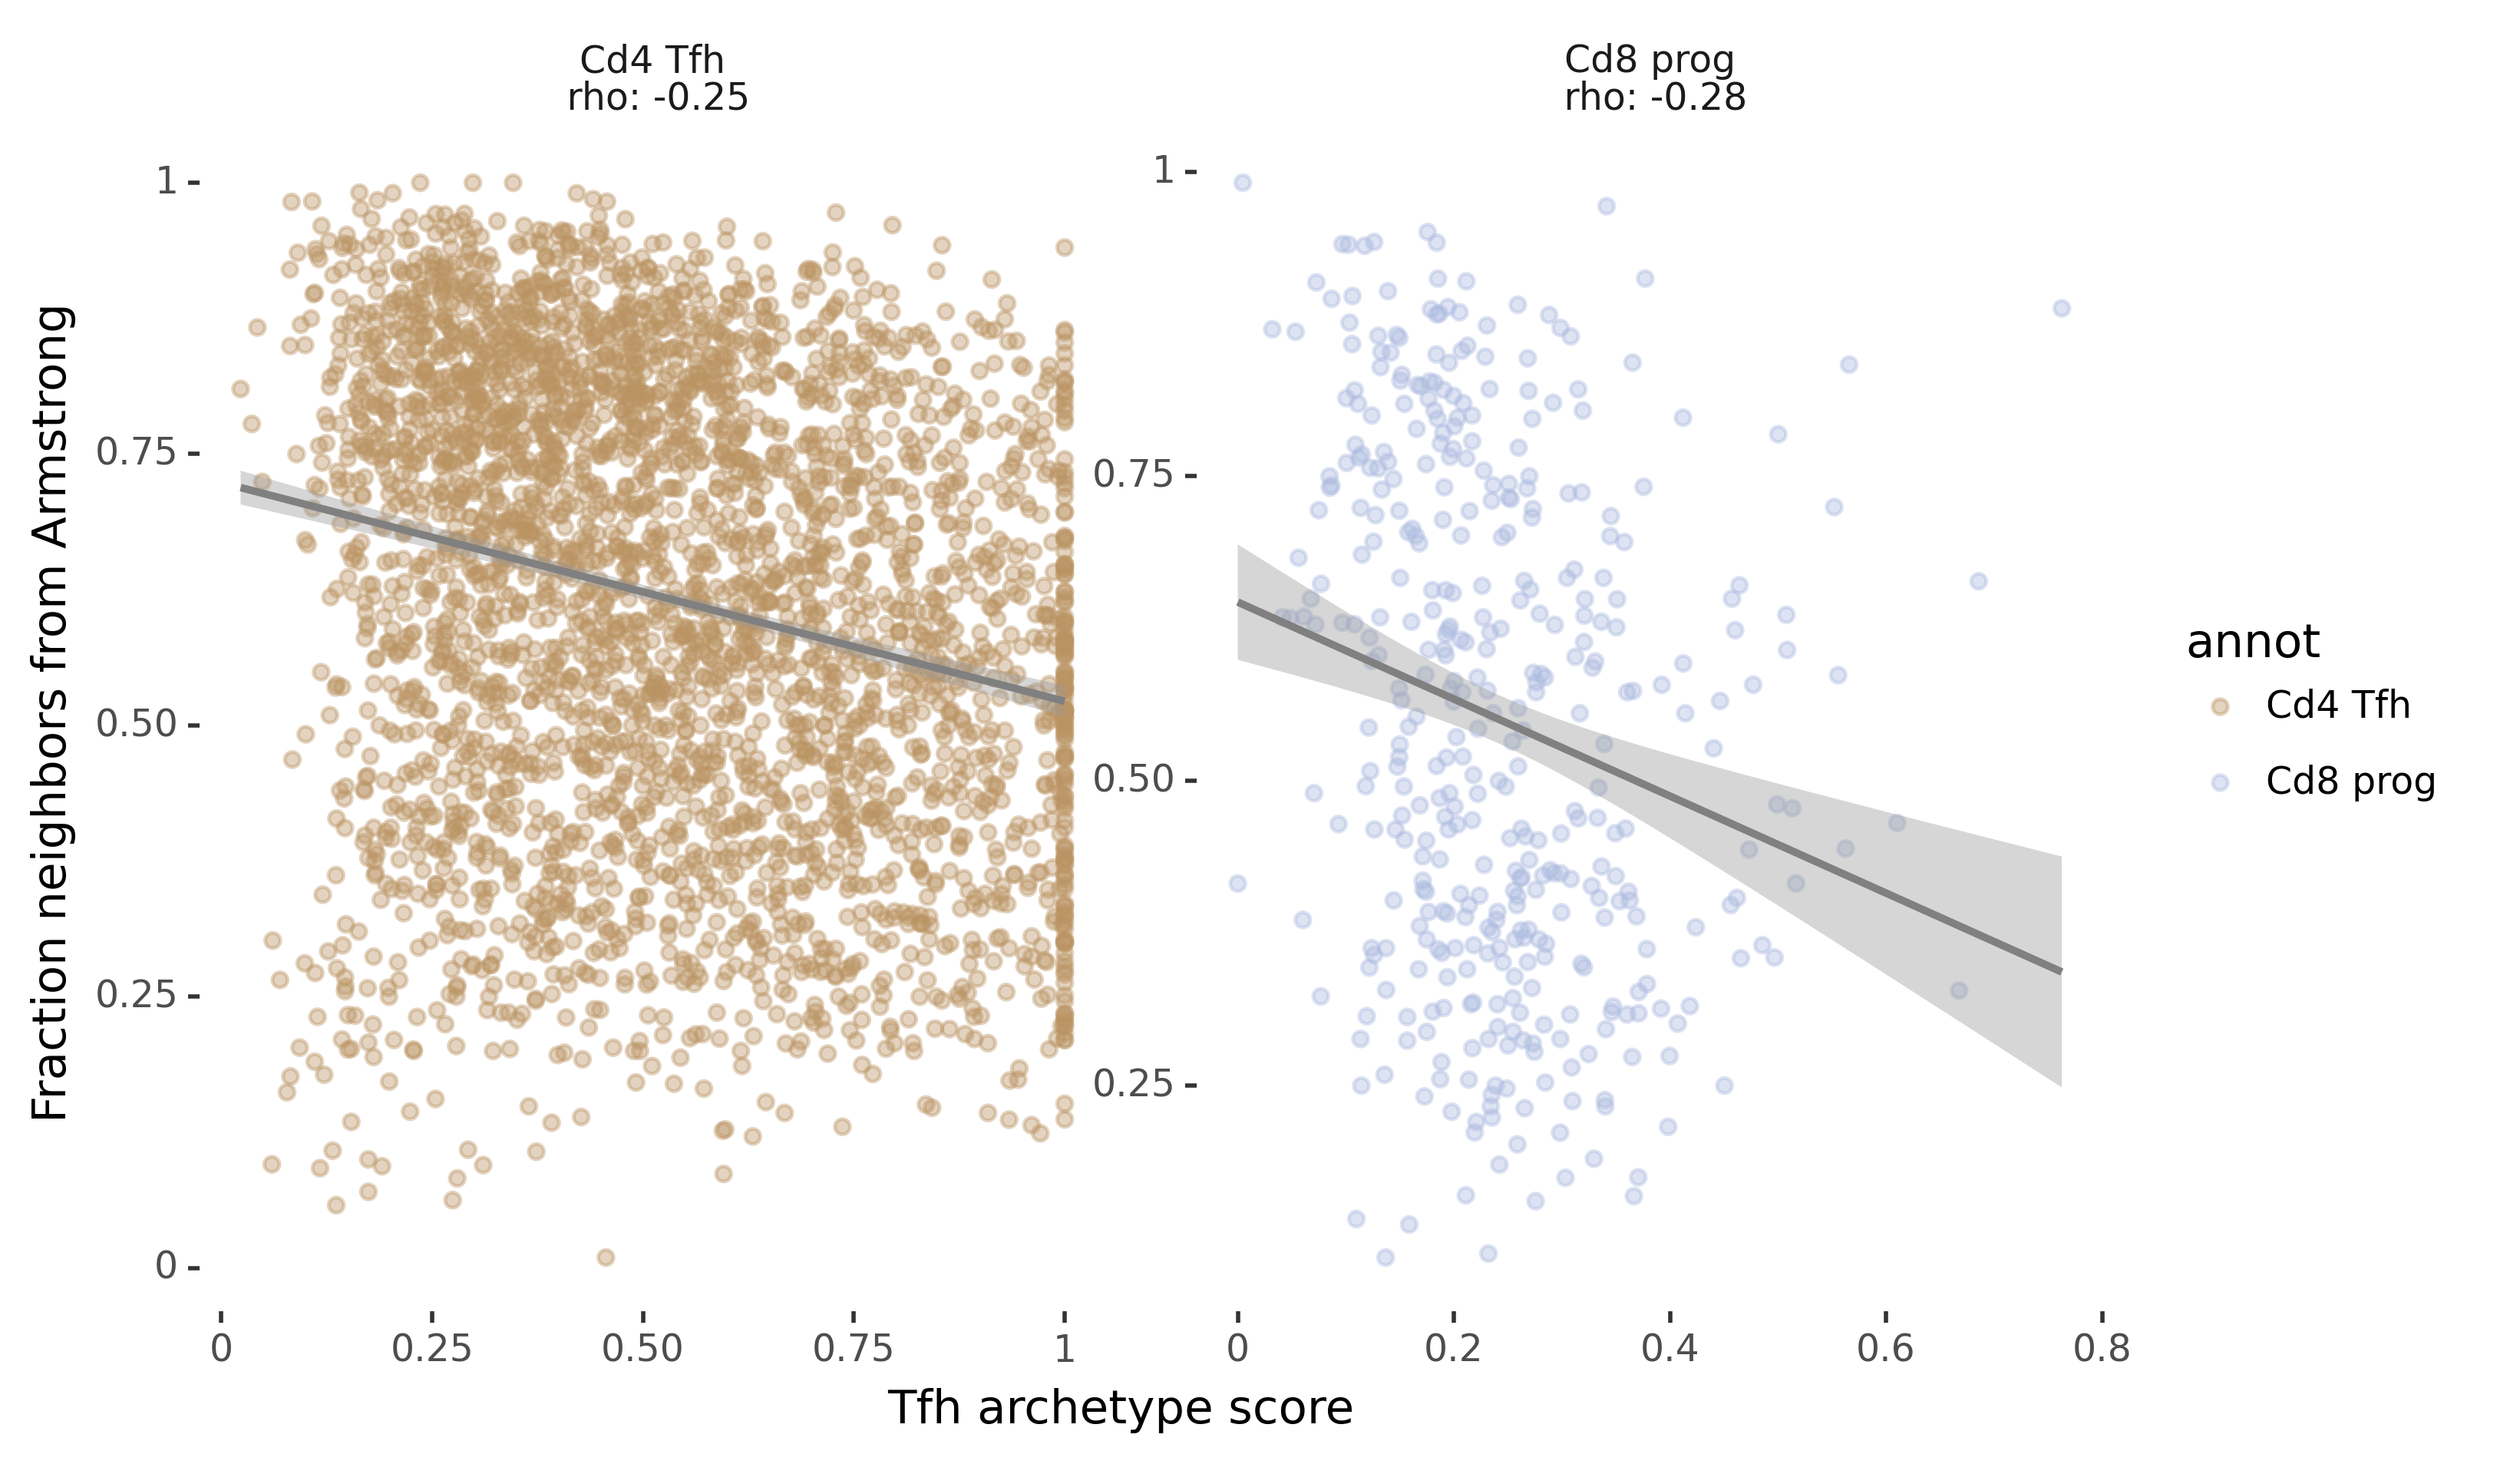

<ggplot: (8775088148221)>

In [17]:
lab_ = lambda x: "%s\n rho: %s"%(x, np.round(spearmanr(rna[rna.obs["final annotation"] == x].obs[
    "Cd4 Tfh arch"], rna[rna.obs["final annotation"] == x].obs["fr_neighbors_armstrong"])[0], 2))

final_e = ggplot(rna[rna.obs["final annotation"].isin(["Cd4 Tfh", "Cd8 prog"])].obs.rename(columns = {
    "final annotation": "annot"}), aes(x="Cd4 Tfh arch", y="fr_neighbors_armstrong", color = "annot")) + \
geom_point(alpha = 0.4) + geom_smooth(color = "gray", se = True, method = "gls") + theme_tufte() +  labs(
    x = "Tfh archetype score", y = "Fraction neighbors from Armstrong") + theme(dpi = 200, subplots_adjust = {
    'wspace': 0.1}, figure_size = (8, 5)) + facet_wrap("~ annot", scales = "free", labeller = lab_) + \
scale_color_manual(rna[rna.obs["final annotation"].isin(["Cd4 Tfh", "Cd8 prog"])].uns["final annotation_colors"])
final_e

In [18]:
ggsave(final_e, "fig6_plots/final_e.scatterplot.pdf", dpi = 300)

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:718: PlotnineWarning: Saving 8 x 5 in image.
/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/ggplot.py:719: PlotnineWarning: Filename: fig6_plots/final_e.scatterplot.pdf


## PANEL F,G: in code for supplemental figure 2

In [24]:
rna_arch_quantiles = pd.DataFrame(rna[rna.obs["final annotation"] == "Cd4 Tfh"].obs["Cd4 Tfh arch"].quantile(
    [0.2, 0.4, 0.6, 0.8]))
lower_q = 0
count_q_cells = pd.DataFrame()
for i, row in rna_arch_quantiles.iterrows():
    q = row["Cd4 Tfh arch"]
    count_q_cells = pd.concat([count_q_cells, pd.DataFrame({"type": t, "q": i, "n cells": "%s cells"%np.sum((
        rna.obs["final annotation"] == "Cd4 Tfh") & (rna.obs["type"] == t) & (rna.obs["Cd4 Tfh arch"] <= q) & (
        rna.obs["Cd4 Tfh arch"] >= lower_q)), "x": np.mean([lower_q, q])} for t in ["arm", "cl13"])])
    lower_q = q
count_q_cells = pd.concat([count_q_cells, pd.DataFrame({"type": t, "q": i, "n cells": "%s cells"%np.sum((
        rna.obs["final annotation"] == "Cd4 Tfh") & (rna.obs["type"] == t) & (rna.obs[
    "Cd4 Tfh arch"] >= rna_arch_quantiles.max()["Cd4 Tfh arch"])),"x": np.mean([lower_q, 1])} for t in [
    "arm", "cl13"])])
count_q_cells    

,type,q,n cells,x
0,arm,0.2,473 cells,0.149976
1,cl13,0.2,222 cells,0.149976
0,arm,0.4,457 cells,0.368932
1,cl13,0.4,238 cells,0.368932
0,arm,0.6,433 cells,0.512103
1,cl13,0.6,262 cells,0.512103
0,arm,0.8,385 cells,0.678231
1,cl13,0.8,310 cells,0.678231
0,arm,0.8,338 cells,0.885084
1,cl13,0.8,357 cells,0.885084


In [21]:
samp_colors = {"arm": "#69659a", "cl13": "#709585"}

/Genomics/argo/users/skwalker/lipstic_env_testing/lib/python3.9/site-packages/plotnine/stats/stat_bin.py:95: PlotnineWarning: 'stat_bin()' using 'bins = 19'. Pick better value with 'binwidth'.


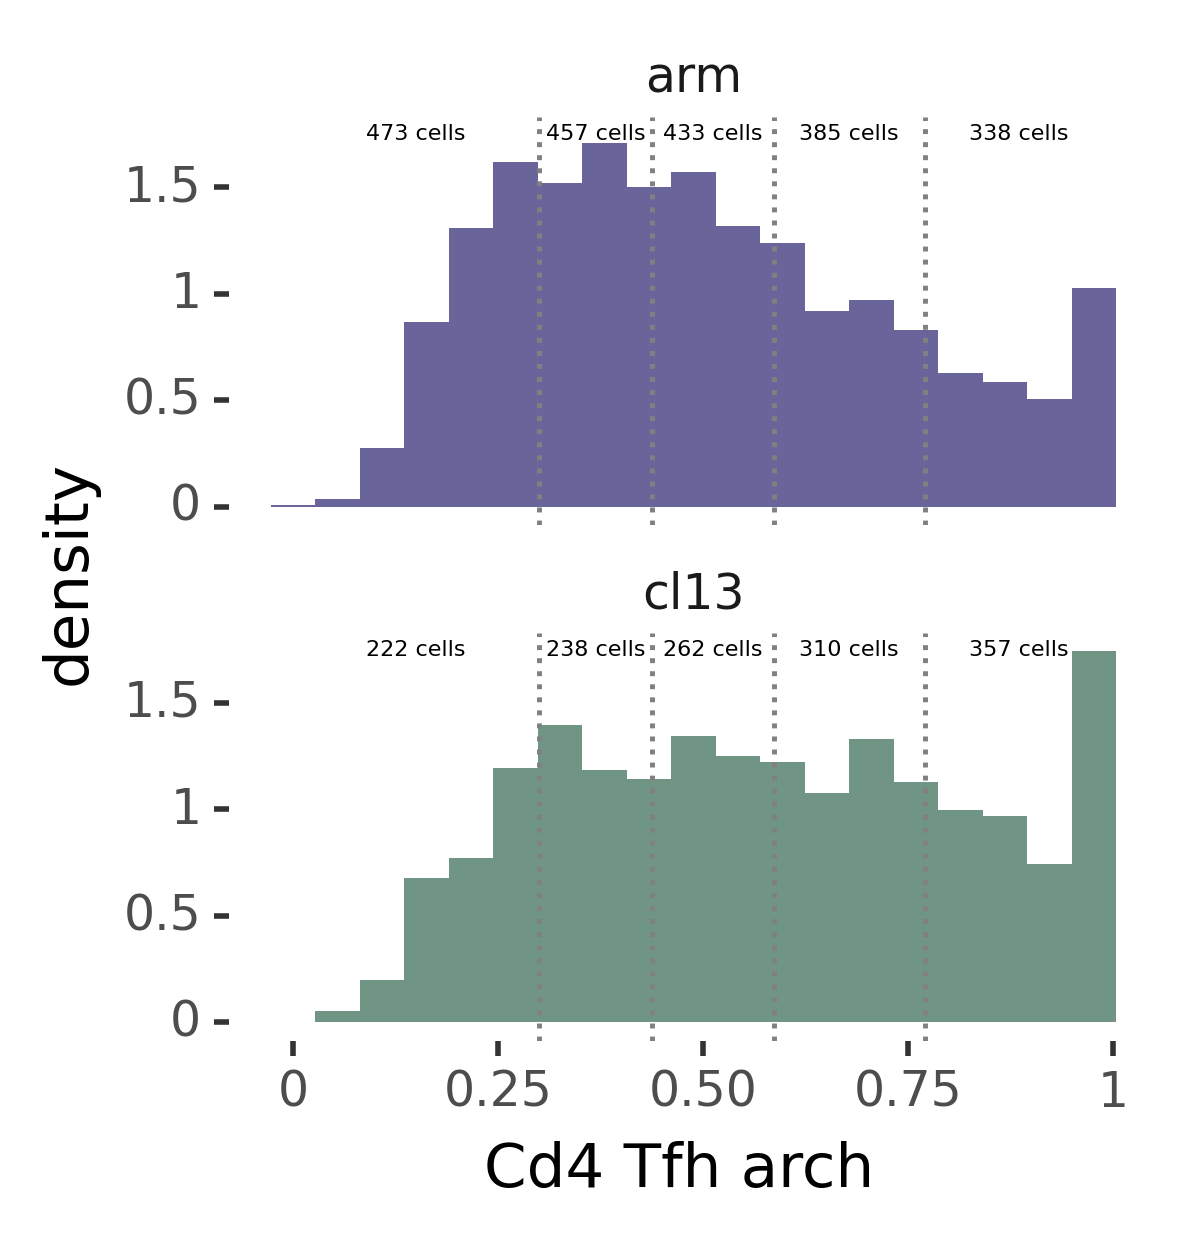

<ggplot: (8775078913247)>

In [25]:
potential_supp_fig = ggplot(rna[rna.obs["final annotation"] == "Cd4 Tfh"].obs, aes(x="Cd4 Tfh arch", y = after_stat(
    'density'), fill = "type")) + theme_tufte() +  geom_histogram() + theme(dpi = 200, figure_size = (
    3, 3), legend_position = "none") + facet_wrap("~ type", ncol = 1) + geom_vline(aes(
    xintercept = "Cd4 Tfh arch"), data = rna_arch_quantiles, linetype = "dotted", color = "gray") + geom_text(aes(
x = "x", label = "n cells"), inherit_aes = False, size = 4, y = 1.75, data = count_q_cells) + scale_fill_manual(
samp_colors)
potential_supp_fig